In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('/home/mingxuanzhang/PerturbVAE/PerturbVAE')

from model import *
from utils import *
from dataset import *
from train import *

In [2]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/PerturbVAE/data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [3]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

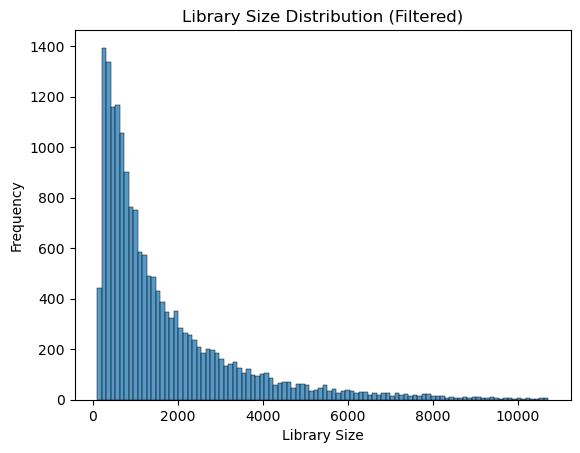

In [4]:
sns.histplot(data.obs['library_size'], bins=100)
plt.xlabel('Library Size')
plt.ylabel('Frequency')
plt.title('Library Size Distribution (Filtered)')
plt.show()

In [5]:
dataset = PerturbDataset(data)

In [6]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [7]:
%load_ext autoreload
%autoreload 2

In [8]:
x = torch.tensor(dataset.X, dtype=torch.float32)
cov = x.T @ x / (x.shape[0] - 1)
cov = cov + torch.eye(cov.shape[0]) * 1e-6  # Add small value to diagonal for numerical stability

In [9]:
import seaborn as sns

In [10]:
def _normalize(cov, eps=1e-12):
    std = np.sqrt(np.diag(cov))
    std[std < eps] = np.inf
    denom = np.outer(std, std)
    corr = cov / denom
    np.fill_diagonal(corr, 1.0)        
    return corr

In [11]:
corr = _normalize(cov.numpy())
corr.shape

(2218, 2218)

In [12]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform

def corr_to_modules(corr: np.ndarray,
                    n_clusters: int | None = None,
                    linkage_method: str = "average",
                    balance: bool = False) -> dict[int, list[int]]:
    dist_vec = squareform(1.0 - np.abs(corr), checks=False)
    Z = linkage(dist_vec, method=linkage_method)
    if balance and n_clusters is not None:
        # dendrogram leaf order keeps similar genes adjacent
        order = leaves_list(Z)
        N = len(order)

        # compute target block sizes: first `n_big` blocks get +1 gene
        base = N // n_clusters
        n_big = N % n_clusters          # #clusters that will be one gene larger

        modules = {}
        idx = 0
        for m in range(1, n_clusters + 1):
            size = base + (1 if m <= n_big else 0)
            modules[m] = order[idx: idx + size].tolist()
            idx += size
        return modules


In [13]:
gene_module_dict = corr_to_modules(corr, n_clusters=16, linkage_method='average', balance=True)
for k, v in gene_module_dict.items():
    print(f"Module {k}: {len(v)} genes")

Module 1: 139 genes
Module 2: 139 genes
Module 3: 139 genes
Module 4: 139 genes
Module 5: 139 genes
Module 6: 139 genes
Module 7: 139 genes
Module 8: 139 genes
Module 9: 139 genes
Module 10: 139 genes
Module 11: 138 genes
Module 12: 138 genes
Module 13: 138 genes
Module 14: 138 genes
Module 15: 138 genes
Module 16: 138 genes


In [14]:
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

import pyro.distributions as dist
import torch.nn as nn
from tqdm import tqdm 
from sklearn.metrics import r2_score
from model import VAE



# Initialize the VAE
pyro.clear_param_store()

input_dim = data.shape[-1] 
latent_dim = len(gene_module_dict.keys())
vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100, 5.0, module_dict=gene_module_dict)
vae = vae.to(vae.device)

# Optimizer and SVI
optimizer = Adam({"lr": 5e-4})
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

# Example training loop
print("Training VAE...", vae.device)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    all_actuals = []
    all_predictions = []
    cls_loss = 0
    for X, P, C in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
        # Move data to the same device as the model
        X = X.to(vae.device).float()
        P = P.to(vae.device).int()
        C = C.to(vae.device).int()
        
        loss = svi.step(X, P, C)
        epoch_loss += loss
        losses.append(loss)
        
        with torch.no_grad(), poutine.trace() as tr:
            vae.model(X, P, C)         
        node = tr.trace.nodes.get("cls_p")
        cls_loss += node["fn"].log_factor[0]
        
        with torch.no_grad():
            z_loc, _ = vae.z_encoder(torch.cat([X,vae.p_emb(P)], dim=-1)) # Latent space
            decoded_logits = vae.z_decoder(z_loc)               # Reconstructed data
            mu = torch.softmax(decoded_logits, dim=-1)
            total_counts = X.sum(-1, keepdim=True)
            x_mu = total_counts * mu

            all_actuals.append(X.cpu().numpy())
            all_predictions.append(x_mu.cpu().numpy())

    # Calculate R² at the end of the epoch
    all_actuals = np.concatenate(all_actuals, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    r2 = r2_score(all_actuals.flatten(), all_predictions.flatten())
    
    # print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}, Classification Loss: {cls_loss:.4f}")

Training VAE... cuda


Epoch 1, Loss: 2552.4030, R²: 0.4974, Classification Loss: -81914.3906


Epoch 2, Loss: 1966.7355, R²: 0.6283, Classification Loss: -135617.0000


Epoch 3, Loss: 1874.8946, R²: 0.6514, Classification Loss: -208183.4844


Epoch 4, Loss: 1858.7333, R²: 0.6620, Classification Loss: -261269.2031


...

Epoch 6, Loss: 1837.4705, R²: 0.6785, Classification Loss: -335353.2188


Epoch 7, Loss: 1832.0871, R²: 0.6825, Classification Loss: -364815.6875


Epoch 8, Loss: 1825.2477, R²: 0.6837, Classification Loss: -383079.9062


Epoch 9, Loss: 1818.9449, R²: 0.6908, Classification Loss: -402528.4688


Epoch 10, Loss: 1815.5554, R²: 0.6930, Classification Loss: -417791.8750


In [15]:
vae.total_counts.max()

7327.0

In [16]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):        # list() -> safe while mutating
    param_store[name] = value.to(torch.device('cpu'))             # keep grad history

X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)
trace_model = poutine.trace(model.model).get_trace(X, P, C)

cpu


In [17]:
z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

In [18]:
correct = 0
total   = 0

logits = model.z_prediction_head(z) 
y_pred = logits.argmax(dim=-1) 
correct += (y_pred == P).sum().item()
total   += P.size(0)

accuracy = correct / total
print(f"Classification accuracy: {accuracy:.4f}")

Classification accuracy: 0.9979


/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


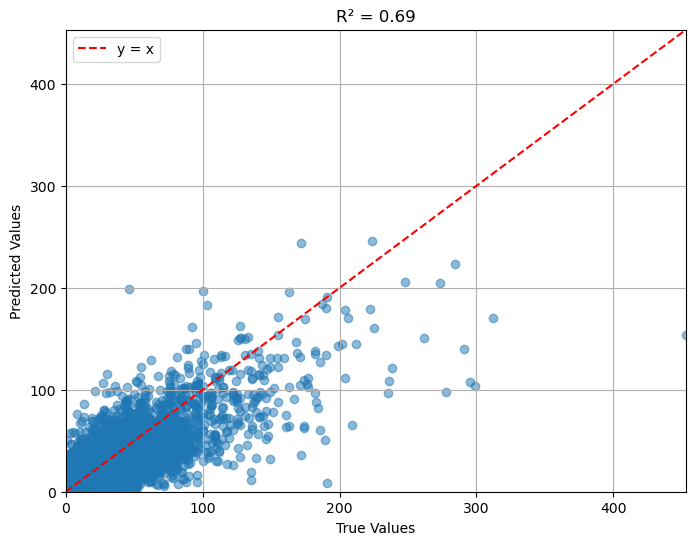

In [19]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
rho = trace.nodes["rho"]["value"]
print(rho.shape)
#rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

#data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


torch.Size([100, 16])


In [21]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

In [22]:
z_data = data.copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)

In [23]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

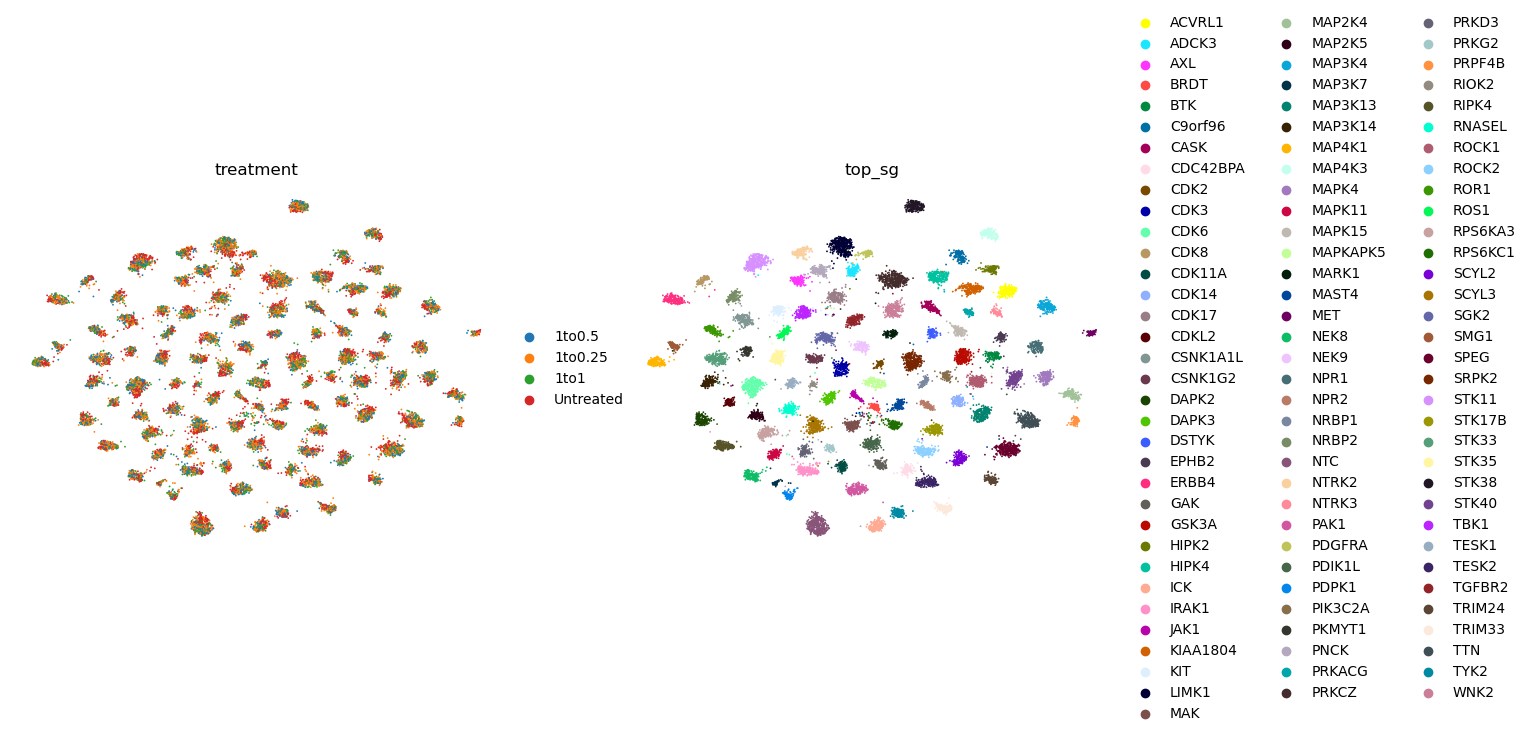

In [24]:
sc.pl.umap(z_data, color=['treatment', 'top_sg'], frameon=False, show=True)

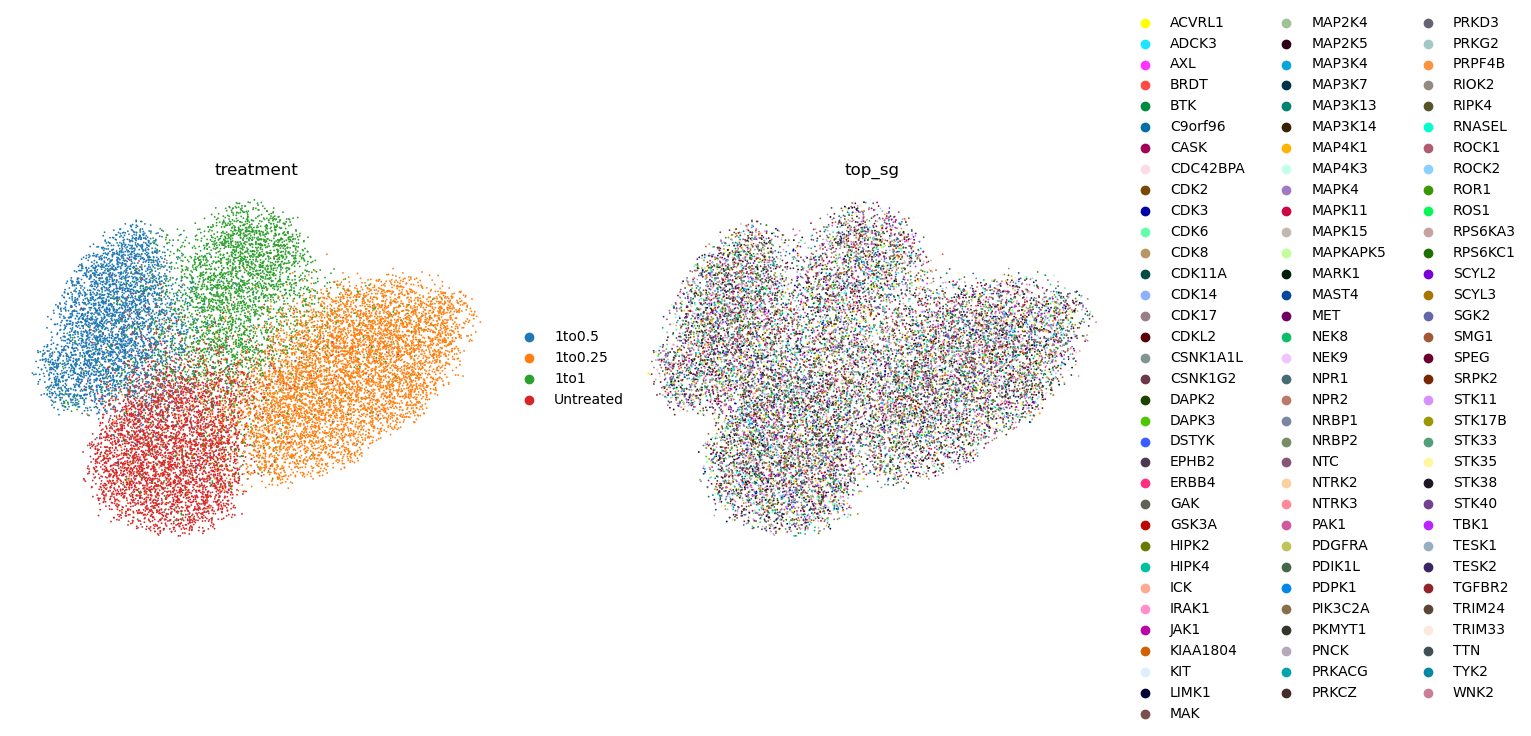

In [25]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [26]:
s_gate = trace.nodes["s_gate"]['value']
rho = trace.nodes['rho']['value'].detach().cpu()
A = model.rho_dec(rho)/math.sqrt(model.latent_dim)  # (P,d)
W = A.detach().cpu().numpy()*s_gate.detach().cpu().numpy()  # (P,d)

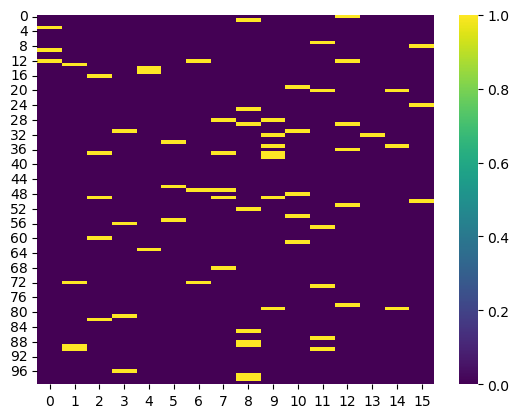

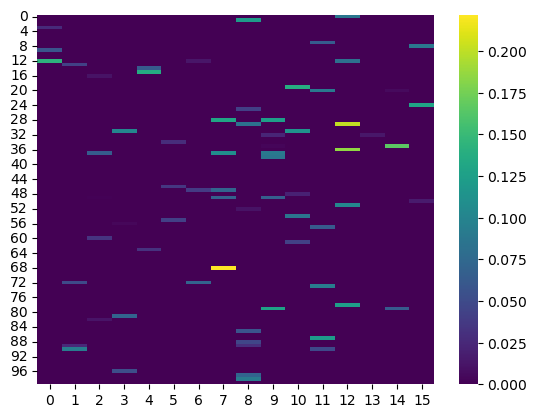

In [27]:
sns.heatmap(s_gate.detach().cpu().numpy(), cmap='viridis')
plt.show()
sns.heatmap(np.abs(W), cmap='viridis')
plt.show()

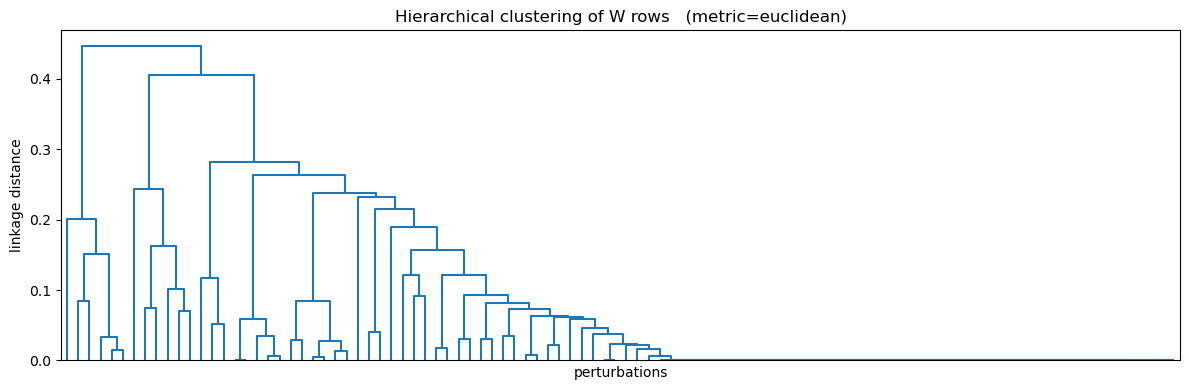

In [28]:
import numpy as np, pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

W_norm = (W - W.mean(0)) / W.std(0, ddof=1)


metric  = "euclidean"  # 'euclidean', 'cosine', 'correlation'
dist_mat = pdist(W, metric=metric)    

link = linkage(dist_mat, method="ward")

plt.figure(figsize=(12, 4))
dendrogram(link, no_labels=True, color_threshold=0.0, count_sort=True)
plt.title(f"Hierarchical clustering of W rows   (metric={metric})")
plt.xlabel("perturbations")
plt.ylabel("linkage distance")
plt.tight_layout()
plt.show()

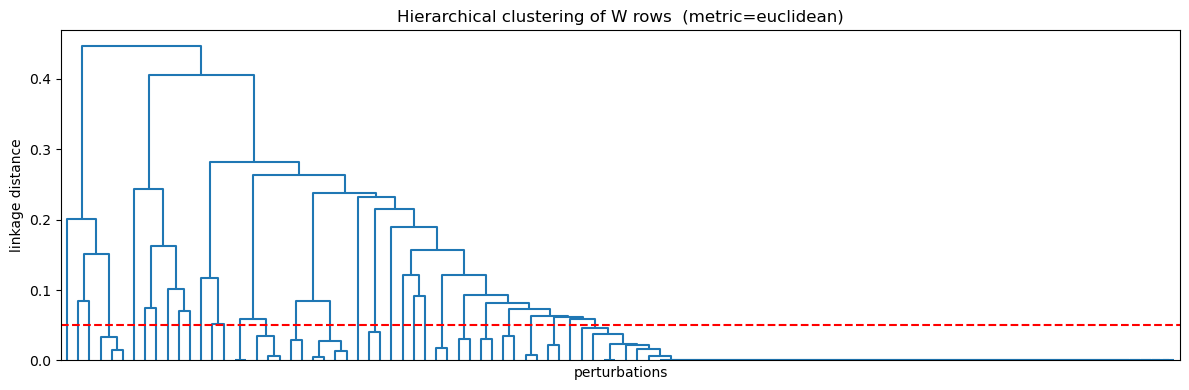


Cluster 1  (n=3)
   • ACVRL1
   • NPR1
   • RPS6KC1

Cluster 2  (n=1)
   • JAK1

Cluster 3  (n=1)
   • MAP3K13

Cluster 4  (n=1)
   • CDK3

Cluster 5  (n=1)
   • IRAK1

Cluster 6  (n=1)
   • MAP3K14

Cluster 7  (n=1)
   • MAP3K4

Cluster 8  (n=1)
   • NEK8

Cluster 9  (n=1)
   • SCYL2

Cluster 10  (n=1)
   • PRKG2

Cluster 11  (n=1)
   • DAPK3

Cluster 12  (n=1)
   • NRBP2

Cluster 13  (n=1)
   • KIT

Cluster 14  (n=2)
   • CDC42BPA
   • NTRK3

Cluster 15  (n=3)
   • DSTYK
   • ROCK1
   • STK33

Cluster 16  (n=4)
   • HIPK2
   • STK11
   • STK35
   • TTN

Cluster 17  (n=2)
   • ADCK3
   • TYK2

Cluster 18  (n=2)
   • CDK11A
   • GSK3A

Cluster 19  (n=2)
   • SGK2
   • TRIM33

Cluster 20  (n=2)
   • CDK8
   • PKMYT1

Cluster 21  (n=2)
   • BRDT
   • CDK14

Cluster 22  (n=2)
   • CDK6
   • STK38

Cluster 23  (n=2)
   • MAP2K4
   • MARK1

Cluster 24  (n=2)
   • MET
   • PDPK1

Cluster 25  (n=54)
   • AXL
   • BTK
   • C9orf96
   • CASK
   • CDK17
   • CDK2
   • CSNK1A1L
   • CSNK1G2
   •

In [29]:

thresh = 0.05

plt.figure(figsize=(12, 4))
dendrogram(link, no_labels=True, color_threshold=0.0, count_sort=True)

plt.axhline(y=thresh, color="red", linestyle="--", linewidth=1.5)

plt.title(f"Hierarchical clustering of W rows  (metric={metric})")
plt.xlabel("perturbations")
plt.ylabel("linkage distance")
plt.tight_layout()
plt.show()

clusters = fcluster(link, thresh, criterion="distance")

idx_to_name = {idx: name for name, idx in dataset.perturbation_dict.items()}

grouped = {}                             # cluster_id -> list[str]
for idx, c in enumerate(clusters):
    grouped.setdefault(c, []).append(idx_to_name[idx])

for c_id, names in sorted(grouped.items()):
    print(f"\nCluster {c_id}  (n={len(names)})")
    for n in names:
        print("   •", n)
